# Datenanalyse mit SQL & Python - Tag 4: Übungen

**Teil A:** Warm-up mit Shop-Daten als Recap zu Tag 3  
**Teil B:** Cleaning, EDA & Reporting mit messy HR Data  
**Mini-Projekt:** Welche Faktoren hängen mit Gehaltsstruktur oder Fluktuationsrisiko im HR-Datensatz zusammen?


## Lernziele

In diesen Übungen trainierst du:

- Inhalte vom Vortag mit Shop-Daten zu wiederholen: Pandas-Überblick, Data Quality Check, `merge`, Feature Engineering, `groupby`, Pivot und Visualisierung
- eine kleine Business-Frage aus Shop-Daten datenbasiert zu beantworten
- einen messy HR-Datensatz zu prüfen und zu bereinigen
- HR-Kennzahlen mit Pandas und SQL zu analysieren
- Verteilungen, Gruppenunterschiede und Korrelationen zu visualisieren
- aus HR-Daten eine datenbasierte Handlungsempfehlung abzuleiten


# 09:00–09:30 | Tag-3-Refresh

## Einrichtung & Daten laden

Führe diese Zelle zuerst aus. Sie lädt:

- `shop_joined` für den Warm-up
- `hr_raw` aus dem Messy-dataset Repository
- `hr` als Arbeitskopie für Cleaning und EDA


In [43]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 100)

SHOP_DIR = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/shop/'
orders = pd.read_csv(SHOP_DIR + 'shop_orders.csv')
customers = pd.read_csv(SHOP_DIR + 'shop_customers.csv')
products = pd.read_csv(SHOP_DIR +  'shop_products.csv')

shop_joined = orders.merge(customers, on='customer_id', how='left').merge(products, on='product_id', how='left')
shop_joined['revenue'] = shop_joined['quantity'] * shop_joined['price']

HR_DATA_URL = 'https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/messy_HR_data.csv'
hr_raw = pd.read_csv(HR_DATA_URL, engine='python', on_bad_lines='warn')
hr = hr_raw.copy()

print('shop_joined:', shop_joined.shape)
print('hr_raw:', hr_raw.shape)
hr_raw.head()


shop_joined: (50, 11)
hr_raw: (1000, 10)


,Name,Age,Salary,Gender,Department,Position,Joining Date,Performance Score,Email,Phone Number
0,grace,25,50000,Male,HR,Manager,"April 5, 2018",D,email@example.com,NaN
1,david,NaN,65000,Female,Finance,Director,2020/02/20,F,user@domain.com,123-456-7890
2,hannah,35,SIXTY THOUSAND,Female,Sales,Director,01/15/2020,C,email@example.com,098-765-4321
3,eve,NaN,50000,Female,IT,Manager,"April 5, 2018",A,name@company.org,
4,grace,NaN,NAN,Female,Finance,Manager,01/15/2020,F,name@company.org,098-765-4321


## Teil A: 30-Minuten-Refresh mit Shop-Daten als Recap zu Tag 3

Arbeite mit `shop_joined`. Ziel ist, die wichtigsten Inhalte vom Vortag aktiv zu wiederholen: DataFrame-Überblick, Data Quality, `merge`, neue Kennzahlen, `groupby`, Pivot und Visualisierung.

**Business-Frage für den Refresh:** Welche Städte und Produktkategorien tragen am stärksten zum Umsatz bei?

**Timing-Vorschlag:**

- A1-A2: 8 Minuten Daten verstehen und Qualität prüfen
- A3-A4: 10 Minuten Kennzahlen und Aggregationen
- A5-A6: 10 Minuten Pivot, Visualisierung und kurze Interpretation
- 2 Minuten Austausch im Plenum


### Übung A1: DataFrame-Überblick (ca. 4 Minuten)

**Aufgabe:** Zeige die ersten Zeilen, die Form, die Spaltennamen und die Datentypen von `shop_joined`.


In [ ]:
shop_joined._____()


In [ ]:
shop_joined._____


In [ ]:
shop_joined._____.tolist()


In [ ]:
shop_joined._____()


### Übung A2: Data Quality & Merge-Check (ca. 4 Minuten)

**Aufgabe:** Prüfe, ob nach dem Zusammenführen fehlende Kunden- oder Produktinformationen entstanden sind.

Hinweis: Wenn `name`, `city`, `product_name`, `category` oder `price` fehlen, hat der Join nicht für alle Zeilen passende Informationen gefunden.


In [ ]:
quality_check = shop_joined[['name', 'city', 'product_name', 'category', 'price']]._____().sum()
quality_check


In [ ]:
print('Zeilen:', len(shop_joined))
print('Bestellungen:', shop_joined['order_id']._____())
print('Kunden:', shop_joined['customer_id']._____())
print('Produkte:', shop_joined['product_id']._____())


### Übung A3: Kennzahlen vorbereiten (ca. 5 Minuten)

**Aufgabe:** Erstelle eine Arbeitskopie `shop_analysis` und ergänze zwei neue Spalten:

- `revenue_per_item`: Umsatz pro Stück
- `age_group`: Altersgruppe der Kundinnen und Kunden


In [ ]:
shop_analysis = shop_joined.copy()

shop_analysis['revenue_per_item'] = shop_analysis['_____'] / shop_analysis['_____']
shop_analysis['age_group'] = pd.cut(
    shop_analysis['age'],
    bins=[0, 30, 45, 60, 120],
    labels=['bis 30', '31-45', '46-60', '60+']
)

shop_analysis[['age', 'age_group', 'quantity', 'price', 'revenue', 'revenue_per_item']].head()


### Übung A4: `groupby` mit mehreren Kennzahlen (ca. 6 Minuten)

**Aufgabe:** Berechne pro Stadt:

- Gesamtumsatz
- Anzahl Bestellungen
- durchschnittlichen Bestellwert
- durchschnittliche Menge pro Bestellung

Sortiere die Tabelle nach Umsatz absteigend.


In [ ]:
city_report = (
    shop_analysis
    .groupby('_____', as_index=False)
    .agg(
        total_revenue=('_____', 'sum'),
        orders=('_____', 'nunique'),
        avg_order_value=('_____', 'mean'),
        avg_quantity=('_____', 'mean')
    )
    .sort_values('_____', ascending=False)
)
city_report


### Übung A5: Pivot-Tabelle Stadt x Kategorie (ca. 5 Minuten)

**Aufgabe:** Erstelle eine Pivot-Tabelle, die den Umsatz je Stadt und Produktkategorie zeigt.


In [ ]:
city_category_pivot = pd.pivot_table(
    shop_analysis,
    index='_____',
    columns='_____',
    values='_____',
    aggfunc='_____',
    fill_value=0
)

city_category_pivot


### Übung A6: Visualisierung & Mini-Interpretation (ca. 8 Minuten)

**Aufgabe:** Visualisiere den Umsatz pro Produktkategorie und formuliere danach eine kurze Business-Aussage.


In [ ]:
category_report = (
    shop_analysis
    .groupby('category', as_index=False)
    .agg(total_revenue=('revenue', 'sum'))
    .sort_values('total_revenue', ascending=False)
)

sns.barplot(data=category_report, x='total_revenue', y='category')
plt.title('Tag-3-Refresh: Umsatz pro Produktkategorie')
plt.xlabel('Umsatz')
plt.ylabel('Kategorie')
plt.show()


In [ ]:
top_category = category_report.iloc[0]
print(f"Business Takeaway: Die Kategorie {top_category['category']} erzielt mit {top_category['total_revenue']:.0f} den höchsten Umsatz.")


# 14:20–15:40 | Praxis mit Day_3_Exercise_Teil B

## Teil B: Cleaning, EDA & Reporting mit messy HR Data

Arbeite mit `hr_raw` und `hr`. Der Datensatz stammt aus dem Repository `eyowhite/Messy-dataset`.

**Business-Kontext:** Die HR-Abteilung möchte verstehen, welche Faktoren mit Gehaltsstruktur, Zufriedenheit oder möglichem Fluktuationsrisiko zusammenhängen.


### Übung B1: Schnell-Check

**Aufgabe:** Prüfe Form, Spalten, Datentypen, fehlende Werte und Duplikate.


In [44]:
print('Form:', hr_raw.shape)
print()
print('Spalten:')
print(hr_raw.columns.tolist())
print()
print('Datentypen:')
print(hr_raw.dtypes)
print()
print('Fehlende Werte:')
print(hr_raw.isna().sum().sort_values(ascending=False).head(20))
print()
print('Duplikate:', hr_raw.duplicated().sum())


Form: (1000, 10)

Spalten:
['Name', 'Age', 'Salary', 'Gender', 'Department', 'Position', 'Joining Date', 'Performance Score', 'Email', 'Phone Number']

Datentypen:
Name                 str
Age                  str
Salary               str
Gender               str
Department           str
Position             str
Joining Date         str
Performance Score    str
Email                str
Phone Number         str
dtype: object

Fehlende Werte:
Email                390
Phone Number         185
Age                  159
Name                   0
Salary                 0
Gender                 0
Department             0
Position               0
Joining Date           0
Performance Score      0
dtype: int64

Duplikate: 0


### Übung B2: Spalten und Textwerte bereinigen

**Aufgabe:** Vereinheitliche Spaltennamen, entferne Leerzeichen aus Textspalten und wandle leere Strings in `NA` um.


In [45]:
hr = hr_raw.copy()

hr.columns = (
    hr.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

text_cols = hr.select_dtypes(include=['object']).columns
for col in text_cols:
    hr[col] = hr[col].astype('string').str.strip()

hr = hr.replace(r'^\s*$', pd.NA, regex=True)
hr.head()


/var/folders/g3/xwx5rk_j3vgg81zv4cx9701m0000gn/T/ipykernel_46922/1694470959.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = hr.select_dtypes(include=['object']).columns


,name,age,salary,gender,department,position,joining_date,performance_score,email,phone_number
0,grace,25,50000,Male,HR,Manager,"April 5, 2018",D,email@example.com,<NA>
1,david,<NA>,65000,Female,Finance,Director,2020/02/20,F,user@domain.com,123-456-7890
2,hannah,35,SIXTY THOUSAND,Female,Sales,Director,01/15/2020,C,email@example.com,098-765-4321
3,eve,<NA>,50000,Female,IT,Manager,"April 5, 2018",A,name@company.org,<NA>
4,grace,<NA>,NAN,Female,Finance,Manager,01/15/2020,F,name@company.org,098-765-4321


### Übung B3: Zahlen-Spalten erkennen, Problemwerte prüfen und konvertieren

**Warum?** Nach dem Einlesen sind viele Spalten noch `object` oder `string`. Für Kennzahlen, Histogramme und Korrelationen müssen echte Zahlen-Spalten zuerst in numerische Datentypen umgewandelt werden.

**Aufgabe:**

1. Prüfe für jede Spalte, ob mindestens ein Wert numerisch interpretierbar ist.
2. Schau dir pro Kandidat die nicht-numerischen Unique Values an. Das zeigt dir, welche Werte beim Umwandeln zu `NaN` würden.
3. Konvertiere alle Spalten mit `numeric_share > 0` mit `pd.to_numeric(..., errors='coerce')`.
4. Kontrolliere danach erneut `hr.dtypes`.

**Wichtig:** Diese Zellen müssen vor den numerischen Kennzahlen in B5 ausgeführt werden.


In [46]:
# 1) Prüfen: Welche Spalten enthalten überhaupt numerisch interpretierbare Werte?
numeric_candidates = []

for col in hr.columns:
    original = hr[col]
    cleaned = (
        original
        .astype('string')
        .str.strip()
        .str.replace('$', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
    )

    converted = pd.to_numeric(cleaned, errors='coerce')
    non_missing = original.notna()
    numeric_share = converted[non_missing].notna().mean()

    non_numeric_examples = (
        original[non_missing & converted.isna()]
        .astype('string')
        .drop_duplicates()
        .head(8)
        .tolist()
    )

    numeric_candidates.append({
        'column': col,
        'current_dtype': str(original.dtype),
        'numeric_share': numeric_share,
        'non_missing_values': int(non_missing.sum()),
        'non_numeric_examples': non_numeric_examples
    })

numeric_candidates = (
    pd.DataFrame(numeric_candidates)
    .sort_values(['numeric_share', 'non_missing_values'], ascending=False)
)

numeric_candidates


,column,current_dtype,numeric_share,non_missing_values,non_numeric_examples
1,age,string,0.790725,841,[thirty]
2,salary,string,0.690000,1000,"[SIXTY THOUSAND, NAN]"
0,name,string,0.000000,1000,"[grace, david, hannah, eve, jack, charlie, fra..."
3,gender,string,0.000000,1000,"[Male, Female, Other]"
4,department,string,0.000000,1000,"[HR, Finance, Sales, IT, Marketing]"
5,position,string,0.000000,1000,"[Manager, Director, Clerk, Assistant, Analyst]"
6,joining_date,string,0.000000,1000,"[April 5, 2018, 2020/02/20, 01/15/2020, 03-25-..."
7,performance_score,string,0.000000,1000,"[D, F, C, A, B]"
9,phone_number,string,0.000000,624,"[123-456-7890, 098-765-4321, 555-555-5555]"
8,email,string,0.000000,610,"[email@example.com, user@domain.com, name@comp..."


In [47]:
# 2) Konvertieren: Alle Spalten mit numeric_share > 0 werden zu numeric.
# Nicht-numerische Werte in diesen Spalten werden durch errors='coerce' zu NaN.
columns_to_convert = numeric_candidates.loc[
    numeric_candidates['numeric_share'] > 0,
    'column'
].tolist()

print('Konvertierte Spalten:', columns_to_convert)

for col in columns_to_convert:
    cleaned = (
        hr[col]
        .astype('string')
        .str.strip()
        .str.replace('$', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
    )
    hr[col] = pd.to_numeric(cleaned, errors='coerce')

hr.dtypes


Konvertierte Spalten: ['age', 'salary']


name                 string
age                   Int64
salary                Int64
gender               string
department           string
position             string
joining_date         string
performance_score    string
email                string
phone_number         string
dtype: object

### Übung B4: Fehlende Werte und Duplikate nach Cleaning prüfen

**Aufgabe:** Vergleiche den Zustand vor und nach den ersten Cleaning-Schritten.


In [48]:
missing_report = pd.DataFrame({
    'missing_before': hr_raw.isna().sum(),
    'missing_after': hr.isna().sum()
}).fillna(0).astype(int)

print('Form vorher:', hr_raw.shape)
print('Form nachher:', hr.shape)
print('Duplikate nach Cleaning:', hr.duplicated().sum())
missing_report.sort_values('missing_after', ascending=False).head(15)


Form vorher: (1000, 10)
Form nachher: (1000, 10)
Duplikate nach Cleaning: 0


,missing_before,missing_after
email,0,390
phone_number,0,376
age,0,335
salary,0,310
Joining Date,0,0
Name,0,0
Performance Score,0,0
Phone Number,185,0
Position,0,0
Salary,0,0


### Übung B5: Fehlende Gehälter nach Department auffüllen

Nach der Zahlen-Konvertierung hat `salary` viele fehlende Werte, weil Textwerte wie `NAN` oder `SIXTY THOUSAND` nicht sauber numerisch konvertiert werden konnten.

**Aufgabe:** Fülle fehlende `salary`-Werte mit dem Median-Gehalt des jeweiligen `department`.

**Warum Median?** Der Median ist robuster gegen Ausreißer als der Durchschnitt.

**Wichtig:** Wir erstellen eine neue Spalte `salary_filled` und behalten mit `salary_was_imputed` fest, welche Werte ergänzt wurden. So bleibt die Bereinigung transparent.


In [ ]:
salary_missing_before = hr['salary'].isna().sum()

salary_by_department = hr.groupby('department')['salary'].transform('median')
global_salary_median = hr['salary'].median()

hr['salary_filled'] = hr['salary'].fillna(salary_by_department)
hr['salary_filled'] = hr['salary_filled'].fillna(global_salary_median)
hr['salary_was_imputed'] = hr['salary'].isna()

salary_missing_after = hr['salary_filled'].isna().sum()

print('Fehlende salary-Werte vorher:', salary_missing_before)
print('Fehlende salary_filled-Werte nachher:', salary_missing_after)

hr.loc[
    hr['salary_was_imputed'],
    ['name', 'department', 'salary', 'salary_filled', 'salary_was_imputed']
].head(10)


In [ ]:
department_salary_check = (
    hr
    .groupby('department', dropna=False)
    .agg(
        employees=('name', 'count'),
        missing_salary=('salary', lambda s: s.isna().sum()),
        median_salary_original=('salary', 'median'),
        median_salary_filled=('salary_filled', 'median')
    )
    .sort_values('missing_salary', ascending=False)
)

department_salary_check


### B5: Explorative HR-Analyse

Wähle passende Spalten aus dem Datensatz. Je nach tatsächlicher Spaltenstruktur kannst du die folgenden Beispiele anpassen.


### Übung B5: Numerische Kennzahlen

**Aufgabe:** Berechne Kennzahlen für alle numerischen Spalten.


In [49]:
numeric_hr = hr.select_dtypes(include='number')

if numeric_hr.empty:
    print('Keine numerischen Spalten gefunden. Bitte führe zuerst Übung B3 aus und prüfe hr.dtypes.')
else:
    display(numeric_hr.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,665.0,37.338346,9.012949,25.0,25.0,35.0,40.0,50.0
salary,690.0,60260.869565,7831.039009,50000.0,55000.0,65000.0,68750.0,70000.0


### Übung B6: Verteilung einer wichtigen HR-Kennzahl

**Aufgabe:** Wähle eine numerische Spalte, zum Beispiel Gehalt, Alter, Zufriedenheit oder Performance, und visualisiere die Verteilung.


In [50]:
# Wähle eine numerische Spalte aus der Ausgabe von numeric_hr.columns.
# Für die HR-Frage ist salary_filled meistens eine gute Wahl.
numeric_hr.columns


Index(['age', 'salary'], dtype='str')

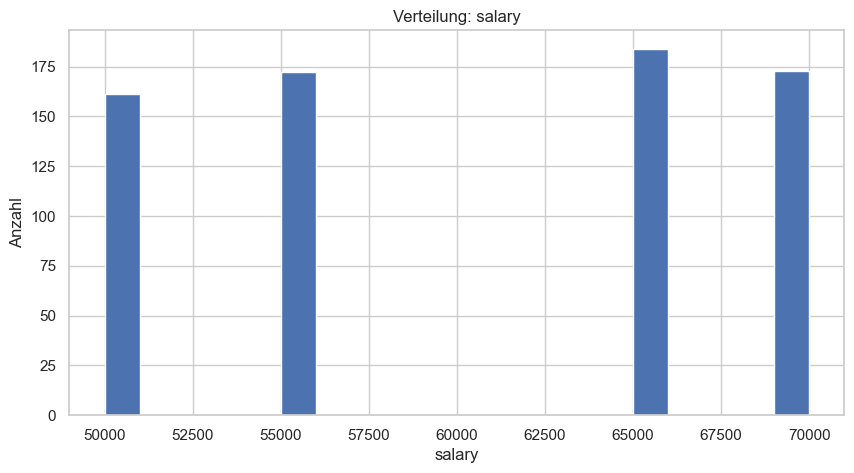

In [55]:
selected_numeric_col = numeric_hr.columns[1]

plt.hist(hr[selected_numeric_col].dropna(), bins=20)
plt.title(f'Verteilung: {selected_numeric_col}')
plt.xlabel(selected_numeric_col)
plt.ylabel('Anzahl')
plt.show()


### Übung B7: Gruppenvergleich

**Aufgabe:** Wähle eine sinnvolle kategoriale Spalte und vergleiche den Durchschnitt einer numerischen HR-Kennzahl pro Gruppe.

**Wichtig:** Nicht jede Textspalte ist eine gute Gruppierungsvariable. `name`, `email` oder `phone_number` identifizieren einzelne Personen und sind für Gruppenvergleiche ungeeignet. Sinnvoller sind zum Beispiel `department`, `gender` oder `position`.


In [52]:
# Sinnvolle Gruppen-Spalten suchen: Textspalten, aber keine ID-/Kontaktspalten.
exclude_group_cols = ['name', 'email', 'phone_number']

categorical_cols = [
    col for col in hr.select_dtypes(include=['object', 'string']).columns
    if col not in exclude_group_cols
]

group_candidates = pd.DataFrame({
    'column': categorical_cols,
    'unique_values': [hr[col].nunique(dropna=True) for col in categorical_cols],
    'examples': [hr[col].dropna().astype('string').drop_duplicates().head(5).tolist() for col in categorical_cols]
}).sort_values('unique_values')

group_candidates


,column,unique_values,examples
0,gender,3,"[Male, Female, Other]"
1,department,5,"[HR, Finance, Sales, IT, Marketing]"
2,position,5,"[Manager, Director, Clerk, Assistant, Analyst]"
3,joining_date,5,"[April 5, 2018, 2020/02/20, 01/15/2020, 03-25-..."
4,performance_score,5,"[D, F, C, A, B]"


In [58]:
# Wähle eine passende Gruppen-Spalte und Kennzahl.
selected_group_col = 'department' if 'department' in categorical_cols else categorical_cols[0]
selected_value_col = 'salary_filled' if 'salary_filled' in numeric_hr.columns else numeric_hr.columns[0]

print('Gruppierung nach:', selected_group_col)
print('Kennzahl:', selected_value_col)

group_report = (
    hr
    .groupby(selected_group_col, dropna=False)[selected_value_col]
    .agg(['count', 'mean', 'median'])
    .query('count >= 2')
    .sort_values('mean', ascending=False)
)
group_report.head(10)


Gruppierung nach: position
Kennzahl: salary


,count,mean,median
position,,,
Director,129,61162.790698,65000.0
Manager,130,60346.153846,65000.0
Analyst,146,60171.232877,65000.0
Clerk,142,60035.211268,55000.0
Assistant,143,59685.314685,55000.0


### Übung B8: Korrelationen

**Aufgabe:** Erstelle eine Korrelationsmatrix für numerische HR-Spalten.


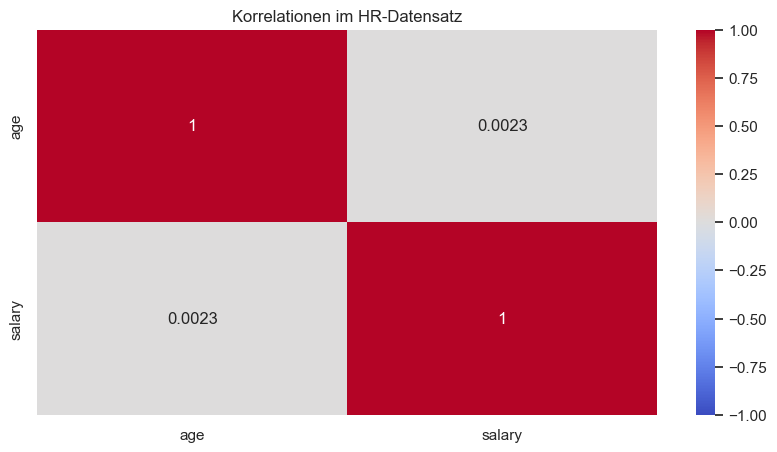

In [59]:
corr = numeric_hr.corr()

sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Korrelationen im HR-Datensatz')
plt.show()


### B6: SQL + Python für HR-Reporting

Speichere den bereinigten HR-DataFrame in SQLite und erstelle eine aggregierte Tabelle.


In [60]:
conn = sqlite3.connect(':memory:')
hr.to_sql('hr', conn, index=False, if_exists='replace')

# Passe group/value bei Bedarf an deine Spalten an.
group_col = selected_group_col
value_col = selected_value_col

query = f'''
SELECT
    "{group_col}" AS gruppe,
    COUNT(*) AS anzahl,
    AVG("{value_col}") AS durchschnitt
FROM hr
WHERE "{value_col}" IS NOT NULL
GROUP BY "{group_col}"
HAVING COUNT(*) >= 2
ORDER BY durchschnitt DESC;
'''

sql_hr_report = pd.read_sql_query(query, conn)
sql_hr_report.head(10)


,gruppe,anzahl,durchschnitt
0,Director,129,61162.790698
1,Manager,130,60346.153846
2,Analyst,146,60171.232877
3,Clerk,142,60035.211268
4,Assistant,143,59685.314685


### B7: Mini-Projekt HR Business Question

**Business Question:**

> Welche Faktoren hängen im HR-Datensatz mit Gehaltsstruktur, Zufriedenheit oder möglichem Fluktuationsrisiko zusammen?

Wähle eine konkrete Variante:

- Welche Abteilung oder Rolle hat auffällig hohe/niedrige Gehälter?
- Gibt es Gruppen mit niedriger Zufriedenheit oder Performance?
- Welche Merkmale könnten auf Fluktuationsrisiko hinweisen?
- Welche HR-Maßnahme würdest du empfehlen?

**Ergebnis:** 2 Diagramme, 3 Erkenntnisse, 1 Empfehlung und 1 Hinweis zur Datenqualität.


In [61]:
hr_insights = [
    'Erkenntnis 1: ...',
    'Erkenntnis 2: ...',
    'Erkenntnis 3: ...',
]
recommendation = 'Empfehlung: ...'
quality_note = 'Datenqualitäts-Hinweis: ...'

for insight in hr_insights:
    print('-', insight)
print(recommendation)
print(quality_note)


- Erkenntnis 1: ...
- Erkenntnis 2: ...
- Erkenntnis 3: ...
Empfehlung: ...
Datenqualitäts-Hinweis: ...


## Abschlussreflexion

Diskutiert kurz:

1. Welche Cleaning-Entscheidung war für die Analyse am wichtigsten?
1. Welche HR-Frage ließ sich gut beantworten?
1. Welche Aussage wäre wegen Datenqualität noch unsicher?
1. Welche zusätzliche HR-Spalte wäre für eine bessere Analyse hilfreich?


## Musterlösungen

Diese Lösungsmuster zeigen einen robusten Weg durch Cleaning, EDA und Reporting. Bei echten messy Daten sind alternative Spaltenauswahlen und Interpretationen möglich.


### Lösungen Teil A: 30-Minuten-Shop-Refresh

In [62]:
# A1: Überblick
shop_joined.head()
shop_joined.shape
shop_joined.columns.tolist()
shop_joined.info()


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   order_id      50 non-null     int64
 1   customer_id   50 non-null     int64
 2   product_id    50 non-null     int64
 3   quantity      50 non-null     int64
 4   name          50 non-null     str  
 5   city          50 non-null     str  
 6   age           50 non-null     int64
 7   product_name  50 non-null     str  
 8   category      50 non-null     str  
 9   price         50 non-null     int64
 10  revenue       50 non-null     int64
dtypes: int64(7), str(4)
memory usage: 4.4 KB


In [63]:
# A2: Data Quality & Merge-Check
quality_check = shop_joined[['name', 'city', 'product_name', 'category', 'price']].isna().sum()
display(quality_check)

print('Zeilen:', len(shop_joined))
print('Bestellungen:', shop_joined['order_id'].nunique())
print('Kunden:', shop_joined['customer_id'].nunique())
print('Produkte:', shop_joined['product_id'].nunique())


name            0
city            0
product_name    0
category        0
price           0
dtype: int64

Zeilen: 50
Bestellungen: 50
Kunden: 19
Produkte: 17


In [64]:
# A3: Kennzahlen vorbereiten
shop_analysis = shop_joined.copy()
shop_analysis['revenue_per_item'] = shop_analysis['revenue'] / shop_analysis['quantity']
shop_analysis['age_group'] = pd.cut(
    shop_analysis['age'],
    bins=[0, 30, 45, 60, 120],
    labels=['bis 30', '31-45', '46-60', '60+']
)

shop_analysis[['age', 'age_group', 'quantity', 'price', 'revenue', 'revenue_per_item']].head()


,age,age_group,quantity,price,revenue,revenue_per_item
0,48,46-60,4,33,132,33.0
1,26,bis 30,3,50,150,50.0
2,25,bis 30,4,13,52,13.0
3,27,bis 30,4,137,548,137.0
4,30,bis 30,3,146,438,146.0


In [65]:
# A4: groupby mit mehreren Kennzahlen
city_report = (
    shop_analysis
    .groupby('city', as_index=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        orders=('order_id', 'nunique'),
        avg_order_value=('revenue', 'mean'),
        avg_quantity=('quantity', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
)
city_report


,city,total_revenue,orders,avg_order_value,avg_quantity
0,Berlin,5499,25,219.960,2.640
1,Cologne,3410,16,213.125,2.375
3,Munich,725,4,181.250,2.250
2,Hamburg,482,5,96.400,2.400


In [ ]:
# A5: Pivot-Tabelle
city_category_pivot = pd.pivot_table(
    shop_analysis,
    index='city',
    columns='category',
    values='revenue',
    aggfunc='sum',
    fill_value=0
)

city_category_pivot


In [ ]:
# A6: Visualisierung & Interpretation
category_report = (
    shop_analysis
    .groupby('category', as_index=False)
    .agg(total_revenue=('revenue', 'sum'))
    .sort_values('total_revenue', ascending=False)
)

sns.barplot(data=category_report, x='total_revenue', y='category')
plt.title('Tag-3-Refresh: Umsatz pro Produktkategorie')
plt.xlabel('Umsatz')
plt.ylabel('Kategorie')
plt.show()

top_category = category_report.iloc[0]
print(f"Business Takeaway: Die Kategorie {top_category['category']} erzielt mit {top_category['total_revenue']:.0f} den höchsten Umsatz.")


### Lösungen Teil B: Cleaning, EDA & Reporting

In [ ]:
# B1
print('Form:', hr_raw.shape)
print('Spalten:', hr_raw.columns.tolist())
print('Duplikate:', hr_raw.duplicated().sum())
hr_raw.isna().sum().sort_values(ascending=False).head(20)


In [ ]:
# B2
hr = hr_raw.copy()
hr.columns = (
    hr.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

text_cols = hr.select_dtypes(include=['object']).columns
for col in text_cols:
    hr[col] = hr[col].astype('string').str.strip()

hr = hr.replace(r'^\s*$', pd.NA, regex=True)
hr.head()


In [ ]:
# B3: Zahlen-Spalten erkennen, Problemwerte prüfen und konvertieren
numeric_candidates = []

for col in hr.columns:
    original = hr[col]
    cleaned = (
        original
        .astype('string')
        .str.strip()
        .str.replace('$', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
    )

    converted = pd.to_numeric(cleaned, errors='coerce')
    non_missing = original.notna()
    numeric_share = converted[non_missing].notna().mean()

    non_numeric_examples = (
        original[non_missing & converted.isna()]
        .astype('string')
        .drop_duplicates()
        .head(8)
        .tolist()
    )

    numeric_candidates.append({
        'column': col,
        'current_dtype': str(original.dtype),
        'numeric_share': numeric_share,
        'non_missing_values': int(non_missing.sum()),
        'non_numeric_examples': non_numeric_examples
    })

numeric_candidates = pd.DataFrame(numeric_candidates).sort_values(
    ['numeric_share', 'non_missing_values'], ascending=False
)
display(numeric_candidates)

columns_to_convert = numeric_candidates.loc[
    numeric_candidates['numeric_share'] > 0,
    'column'
].tolist()

print('Konvertierte Spalten:', columns_to_convert)

for col in columns_to_convert:
    cleaned = (
        hr[col]
        .astype('string')
        .str.strip()
        .str.replace('$', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace(',', '', regex=False)
    )
    hr[col] = pd.to_numeric(cleaned, errors='coerce')

numeric_hr = hr.select_dtypes(include='number')
numeric_hr.describe().T


In [ ]:
# B4
missing_report = pd.DataFrame({
    'missing_before': hr_raw.isna().sum(),
    'missing_after': hr.isna().sum()
}).fillna(0).astype(int)

missing_report.sort_values('missing_after', ascending=False).head(15)


In [ ]:
# B5: Fehlende salary-Werte nach department auffüllen
salary_missing_before = hr['salary'].isna().sum()

salary_by_department = hr.groupby('department')['salary'].transform('median')
global_salary_median = hr['salary'].median()

hr['salary_filled'] = hr['salary'].fillna(salary_by_department)
hr['salary_filled'] = hr['salary_filled'].fillna(global_salary_median)
hr['salary_was_imputed'] = hr['salary'].isna()

print('Fehlende salary-Werte vorher:', salary_missing_before)
print('Fehlende salary_filled-Werte nachher:', hr['salary_filled'].isna().sum())

hr.loc[
    hr['salary_was_imputed'],
    ['name', 'department', 'salary', 'salary_filled', 'salary_was_imputed']
].head(10)


In [ ]:
# B6-B9
numeric_hr = hr.select_dtypes(include='number')
selected_value_col = 'salary_filled' if 'salary_filled' in numeric_hr.columns else numeric_hr.columns[0]

plt.hist(hr[selected_value_col].dropna(), bins=20)
plt.title(f'Verteilung: {selected_value_col}')
plt.xlabel(selected_value_col)
plt.ylabel('Anzahl')
plt.show()

exclude_group_cols = ['name', 'email', 'phone_number']
categorical_cols = [
    col for col in hr.select_dtypes(include=['object', 'string']).columns
    if col not in exclude_group_cols
]

selected_group_col = 'department' if 'department' in categorical_cols else categorical_cols[0]

group_report = (
    hr
    .groupby(selected_group_col, dropna=False)[selected_value_col]
    .agg(['count', 'mean', 'median'])
    .query('count >= 2')
    .sort_values('mean', ascending=False)
)
display(group_report.head(10))

corr = numeric_hr.corr()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Korrelationen im HR-Datensatz')
plt.show()


In [ ]:
# B6 SQL + Python Reporting
conn = sqlite3.connect(':memory:')
hr.to_sql('hr', conn, index=False, if_exists='replace')

query = f'''
SELECT
    "{selected_group_col}" AS gruppe,
    COUNT(*) AS anzahl,
    AVG("{selected_value_col}") AS durchschnitt
FROM hr
WHERE "{selected_value_col}" IS NOT NULL
GROUP BY "{selected_group_col}"
HAVING COUNT(*) >= 2
ORDER BY durchschnitt DESC;
'''

sql_hr_report = pd.read_sql_query(query, conn)
sql_hr_report.head(10)
